In [ ]:
# Colab setup — skip if running locally
import importlib
if importlib.util.find_spec('skimage') is None:
    !pip install -q scikit-image

Consider the L1-norm constrained problem $\min L(\beta) = \| y - X \beta \|_2 ^2 $ subject to $\| \beta \|_1 \leq \lambda$. We implement two methods:
- projected gradient descent
- Frank-Wolfe

# Data Preparation

- Create a Simple Object: We start by creating a 128x128 image with a small circle at the center to serve as our object of interest. This image is then vectorized and used as the signal.

- Vectorization: The 2D image matrix of the object is then flattened into a 1D vector to facilitate mathematical operations.

- Structured Transformation: A structured matrix, designed to simulate sparse projections by mimicking data collection at different angles or frequencies, is used to transform the object vector. This step abstracts the concept of taking projections from various perspectives.

- Projections: Transform the singal using the structed matrix.

- Add Noise: Gaussian noise with a specified standard deviation is added to the projections to simulate the real-world scenario where measurements are affected by noise. This step enhances the realism of the simulation by accounting for the inevitable presence of noise in actual data collection processes.

Our goal later is to reconstruct the signal (object) from data --- $X $ is the structed matrix and $y$ is the noisy version of projections.

Finish data preparation. The dimension of $X$ is (1000, 2500), dimension of $y$ is (1000,)


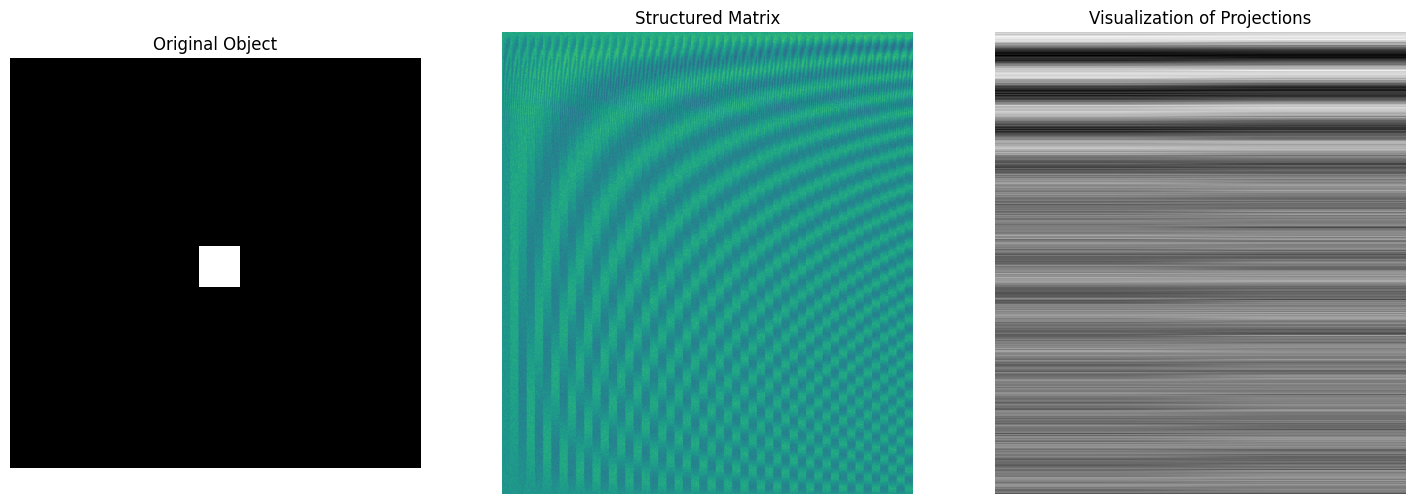

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.draw import disk


#Create a Simple Object - Small Circle
N = 50  # Image dimensions
num_projections = N*20

object_img = np.zeros((N, N), dtype=np.float64)

# Small circle parameters
circle_center = (N // 2, N // 2)
circle_radius = 3
circle_value = 1  # Intensity of the circle

# Draw the circle
rr, cc = disk(circle_center, circle_radius, shape=object_img.shape)
object_img[rr, cc] = circle_value

# Vectorize the image -- this vector is the signal vector we want to recover
object_vector = object_img.flatten()


# Generate a structured transformation matrix using sinusoidal functions
freqs = np.linspace(0, np.pi, num_projections)  # Frequency components
structured_matrix = np.zeros((num_projections, N**2))


# Populate the matrix with sinusoidal patterns
for i, freq in enumerate(freqs):
    for j in range(N**2):
        noise = np.random.normal(0, 1)
        x, y = divmod(j, N)  # Convert index to 2D coordinates
        structured_matrix[i, j] = np.sin(freq * x) + np.cos(freq * y) +  noise

# Apply the structured transformation
projection = structured_matrix @ object_vector

visualization_matrix = projection.reshape((10*N, 2))  # Reshape for visualization purposes

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 3, 1)
plt.imshow(object_img, cmap='gray')
plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 3, 2)
plt.imshow(structured_matrix, cmap='viridis', aspect='auto')
plt.title('Structured Matrix')
plt.axis('off')

# Visualization of Structured Projections (as a 2D reshaped version)
plt.subplot(1, 3, 3)
plt.imshow(visualization_matrix, cmap='gray', aspect='auto')
plt.title('Visualization of Projections')
plt.axis('off')



sigma = 0.2  # Standard deviation (sqrt of variance) for the noise
noise = np.random.normal(0, sigma, projection.shape)

# Add noise to the projections
y = projection + noise
X = structured_matrix
beta_true = object_vector

print(f"Finish data preparation. The dimension of $X$ is {X.shape}, dimension of $y$ is {y.shape}")


# Optimization objective: Least-squares + $\ell_1$-constraint
$$
\min_{\beta} \frac{1}{n} \| y - X \beta \|_2^2  ~~\textrm{subject to}~~  \|\beta\|_1 \leq \lambda.  
$$
This objective is not smooth. We compare two methods:

- (a) projected gradient descent: directly call gradient from automatic differentiation, run constant-stepsize gradient descent, project it.
- (b) Frank-Wolfe: search a descent direction, update.

## Projection to $\ell_1$-ball:

- Sort the absolute values of the elements of $x$ in decreasing order. Let $|x|_{(1)}, |x|_{(2)}, \ldots, |x|_{(n)}$ denote these sorted absolute values, such that $|x|_{(1)} \geq |x|_{(2)} \geq \cdots \geq |x|_{(n)}$.
    
-Find the largest $k \in \{1, \ldots, n\}$ such that
  $$
    \sum_{i=1}^{k} |x|_{(i)} - k \cdot |x|_{(k)} \leq \lambda.
$$
    This step identifies the threshold index \(k\) for which the cumulative sum of the largest \(k\) absolute values, adjusted by the subtraction of \(k\) times the \(k\)-th largest absolute value, first exceeds \(\lambda\).
    
- Compute the threshold $\theta$ as
  $$
    \theta = \frac{1}{k} \left( \sum_{i=1}^{k} |x|_{(i)} - \lambda \right).
$$
    The threshold $\theta$ is used to adjust the magnitude of the elements in $x$ for the projection.
    
-  The projected vector is then obtained by applying the following operation to each element $x_i$ of $x$:
 $$
    \text{proj}_{\ell_1}(x_i) = \text{sign}(x_i) \cdot \max(|x_i| - \theta, 0).
  $$
    This operation reduces the magnitude of each element by $\theta$, preserving the sign of the original elements, and ensuring that the result lies within the \(\ell_1\)-ball of radius $\lambda$.

Reference:
https://stanford.edu/~jduchi/projects/DuchiShSiCh08.pdf



regularization parameter is 2500.0
iteration   1 | objective value 40121.8381
iteration  11 | objective value 2030.1456
iteration  21 | objective value 365.0338
iteration  31 | objective value 164.2200
iteration  41 | objective value 98.2287
iteration  51 | objective value 64.1811
iteration  61 | objective value 43.9426
iteration  71 | objective value 31.1871
iteration  81 | objective value 22.7468
iteration  91 | objective value 16.9549
iteration 101 | objective value 12.8531
iteration 111 | objective value 9.8662
iteration 121 | objective value 7.6631
iteration 131 | objective value 6.0103
iteration 141 | objective value 4.7530
iteration 151 | objective value 3.7852
iteration 161 | objective value 3.0328
iteration 171 | objective value 2.4425
iteration 181 | objective value 1.9764
iteration 191 | objective value 1.6055
Estimation error is 59.9864


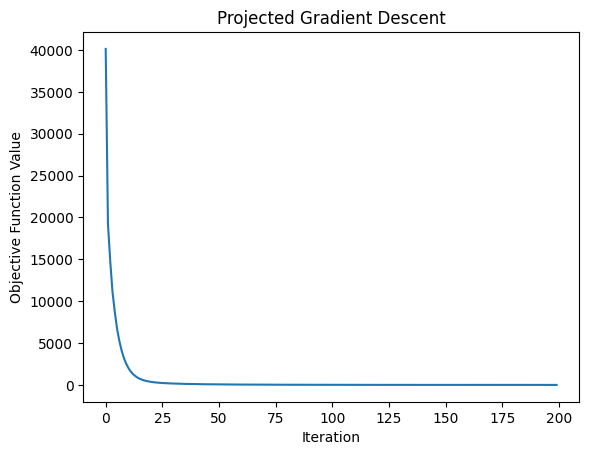

(-0.5, 49.5, 49.5, -0.5)

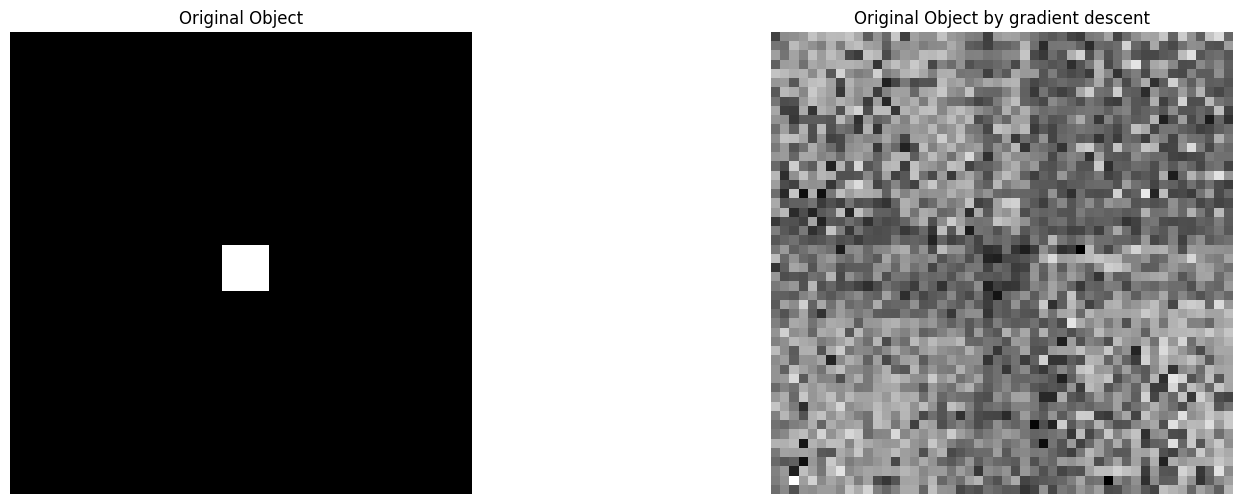

In [ ]:
import numpy as np

def project_to_l1_ball(x, lambda_val):
    """
    Project the vector x onto the l1-ball of radius lambda_val.

    Parameters:
    - x: np.array, the vector to be projected.
    - lambda_val: float, the radius of the l1-ball.

    Returns:
    - np.array, the projected vector.
    """
    # Step 1: Sort the absolute values in decreasing order
    abs_x_sorted = np.sort(np.abs(x))[::-1]
    # Compute the cumulative sum of abs_x_sorted
    cumsum_abs_x_sorted = np.cumsum(abs_x_sorted)

    # Step 2: Find the largest k such that the condition holds
    rho = np.nonzero(abs_x_sorted * np.arange(1, len(x) + 1) > (cumsum_abs_x_sorted - lambda_val))[0][-1]

    # Step 3: Compute the threshold theta
    theta = (cumsum_abs_x_sorted[rho] - lambda_val) / (rho + 1)

    # Step 4: Compute the projected vector
    projected_x = np.sign(x) * np.maximum(np.abs(x) - theta, 0)

    return projected_x



def projected_gradient_descent(y, X, beta_0, stepsize, num_iterations, lambda_val):
    beta = beta_0
    function_values = []
    violation = False
    m,n = np.shape(X)


    for t in range(num_iterations):
        # Compute gradient
        grad = -2 * X.T.dot(y - X @ beta) / m

        # Gradient descent step
        beta_temp = beta - stepsize * grad

        # Projection onto l1-ball

        beta = project_to_l1_ball(beta_temp, lambda_val)
        if np.linalg.norm(beta, 1) > (lambda_val + 1e-3):
            violation = True
            print("constraint is violated")
        # Record the function value
        function_values.append(np.linalg.norm(y- X @ beta)**2 / (2*m))

    return beta, function_values


beta_0 = np.zeros(X.shape[1])
lambda_0 = 100 * np.linalg.norm(beta_true, 1)
stepsize = 0.01
num_iterations = 200

print(f"regularization parameter is {lambda_0}")
final_beta, function_values = projected_gradient_descent(y, X, beta_0, stepsize, num_iterations, lambda_0)

error = np.linalg.norm(final_beta - beta_true)


for i, value in enumerate(function_values):
    if (i+1) % 10 == True:
        print(f"iteration{i + 1:4d} | objective value {value:.4f}")

print(f"Estimation error is {error:.4f}")


# Visualize the objective function value over iterations
plt.plot(function_values)
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.title('Projected Gradient Descent')
plt.show()



# plot the estimated signal
estimated_image = final_beta.reshape(N, N)
original_image = beta_true.reshape(N, N)

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 2, 1)
plt.imshow(object_img, cmap='gray')

plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 2, 2)
plt.imshow(estimated_image, cmap='gray')
plt.title('Original Object by gradient descent')
plt.axis('off')




regularization parameter is 25.25
iteration   1 | objective value 15.4586
iteration  11 | objective value 6.2751
iteration  21 | objective value 3.9112
iteration  31 | objective value 2.6536
iteration  41 | objective value 1.8724
iteration  51 | objective value 1.3601
iteration  61 | objective value 1.0053
iteration  71 | objective value 0.7545
iteration  81 | objective value 0.5735
iteration  91 | objective value 0.4405
iteration 101 | objective value 0.3411
iteration 111 | objective value 0.2661
iteration 121 | objective value 0.2093
iteration 131 | objective value 0.1659
iteration 141 | objective value 0.1326
iteration 151 | objective value 0.1069
iteration 161 | objective value 0.0870
iteration 171 | objective value 0.0716
iteration 181 | objective value 0.0596
iteration 191 | objective value 0.0502
Estimation error is 0.3367


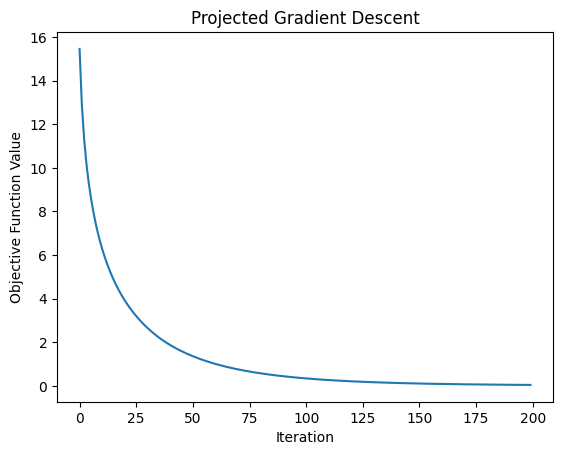

(-0.5, 49.5, 49.5, -0.5)

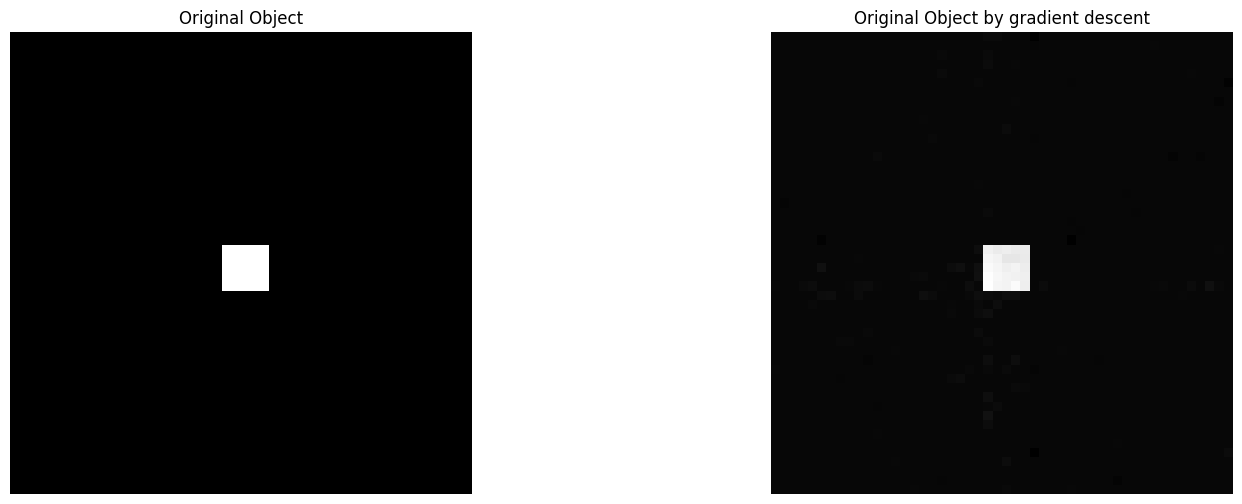

In [ ]:

beta_0 = np.zeros(X.shape[1])
lambda_0 = 1.01 * np.linalg.norm(beta_true, 1)
stepsize = 0.01
num_iterations = 200

print(f"regularization parameter is {lambda_0}")
final_beta, function_values = projected_gradient_descent(y, X, beta_0, stepsize, num_iterations, lambda_0)

error = np.linalg.norm(final_beta - beta_true)


for i, value in enumerate(function_values):
    if (i+1) % 10 == True:
        print(f"iteration{i + 1:4d} | objective value {value:.4f}")

print(f"Estimation error is {error:.4f}")


# Visualize the objective function value over iterations
plt.plot(function_values)
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.title('Projected Gradient Descent')
plt.show()



# plot the estimated signal
estimated_image = final_beta.reshape(N, N)
original_image = beta_true.reshape(N, N)

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 2, 1)
plt.imshow(object_img, cmap='gray')

plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 2, 2)
plt.imshow(estimated_image, cmap='gray')
plt.title('Original Object by gradient descent')
plt.axis('off')




Descent Direction in Frank-Wolfe
To compute the descent direction in the Frank-Wolfe algorithm, given a gradient vector, we find the point in the constraint set that has the maximum alignment (in terms of the dot product) with the negative gradient. For the
$\ell_1$-norm constraint set, this corresponds to selecting a vertex of the $\ell_1$-ball.


In [ ]:
import numpy as np

def frank_wolfe_descent_direction(grad, lambda_val):
    """
    Compute the descent direction for the Frank-Wolfe algorithm.

    Parameters:
    - grad: np.array, the gradient vector of the objective at the current point.
    - lambda_val: float, the radius of the l1-ball (constraint).

    Returns:
    - s: np.array, the descent direction vector.
    """
    s = np.zeros_like(grad)
    index = np.argmax(-grad)  # Find the index of the largest magnitude in -grad
    s[index] = np.sign(-grad[index]) * lambda_val  # Assign lambda_val to this index
    return s


def frank_wolfe(y, X, beta_0, stepsize, num_iterations, lambda_val):
    beta = beta_0
    function_values = []
    m,n = np.shape(X)
    for t in range(num_iterations):
        # Compute the gradient of the objective function at the current beta
        grad = -2 * X.T.dot(y - X.dot(beta)) / m

        # Compute the descent direction using the Frank-Wolfe method
        s = frank_wolfe_descent_direction(grad, lambda_val)

        # Update beta using the computed direction and step size
        gamma = 2 / (t + 2) if stepsize is None else stepsize  # Example step size rule
        beta = (1 - gamma) * beta + gamma * s

        # Record the current value of the objective function
        function_values.append(np.linalg.norm(y - X.dot(beta))**2 / (2*m))

    return beta, function_values




regularization parameter is 25.25
iteration   1 | objective value 73.5402
iteration  11 | objective value 54.2533
iteration  21 | objective value 41.3453
iteration  31 | objective value 32.0858
iteration  41 | objective value 25.2943
iteration  51 | objective value 20.1023
iteration  61 | objective value 16.1654
iteration  71 | objective value 13.0700
iteration  81 | objective value 10.6701
iteration  91 | objective value 8.6574
iteration 101 | objective value 7.1042
iteration 111 | objective value 5.8039
iteration 121 | objective value 4.7107
iteration 131 | objective value 3.8527
iteration 141 | objective value 3.1498
iteration 151 | objective value 2.5757
iteration 161 | objective value 2.1177
iteration 171 | objective value 1.7305
iteration 181 | objective value 1.4031
iteration 191 | objective value 1.1518
iteration 201 | objective value 0.9726
iteration 211 | objective value 0.8032
iteration 221 | objective value 0.6703
iteration 231 | objective value 0.5352
iteration 241 | objec

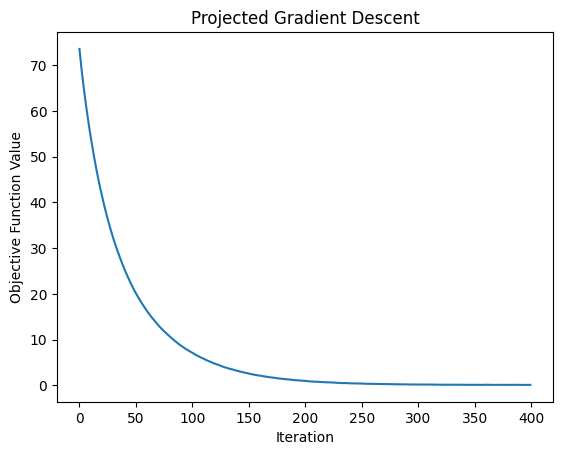

(-0.5, 49.5, 49.5, -0.5)

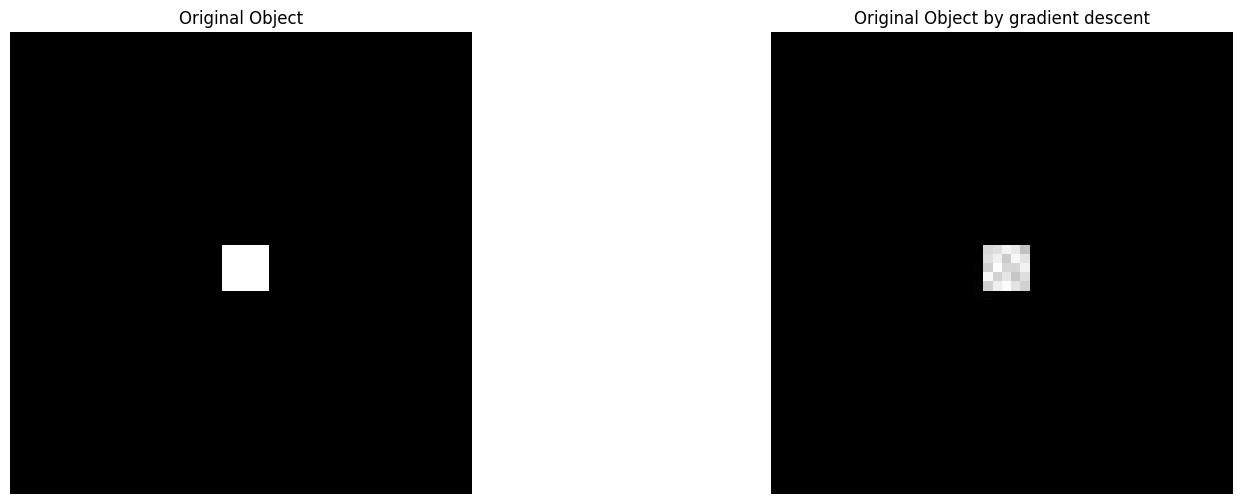

In [ ]:

beta_0 = np.zeros(X.shape[1])
lambda_0 = 1.01 * np.linalg.norm(beta_true, 1)
stepsize = 0.01
num_iterations = 400

print(f"regularization parameter is {lambda_0}")
final_beta, function_values = frank_wolfe(y, X, beta_0, stepsize, num_iterations, lambda_0)

error = np.linalg.norm(final_beta - beta_true)


for i, value in enumerate(function_values):
    if (i+1) % 10 == True:
        print(f"iteration{i + 1:4d} | objective value {value:.4f}")

print(f"Estimation error is {error:.4f}")


# Visualize the objective function value over iterations
plt.plot(function_values)
plt.xlabel('Iteration')
plt.ylabel('Frank Wolfe Function Value')
plt.title('Projected Gradient Descent')
plt.show()



# plot the estimated signal
estimated_image = final_beta.reshape(N, N)
original_image = beta_true.reshape(N, N)

plt.figure(figsize=(18, 6))

# Original Object
plt.subplot(1, 2, 1)
plt.imshow(object_img, cmap='gray')

plt.title('Original Object')
plt.axis('off')

# Structured Matrix Visualization (Simplified)
plt.subplot(1, 2, 2)
plt.imshow(estimated_image, cmap='gray')
plt.title('Original Object by gradient descent')
plt.axis('off')


